<a href="https://colab.research.google.com/github/dityaptra/Maize-Leaf-Classification-System/blob/main/maize_leaf_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistem Klasifikasi Penyakit Daun Jagung dengan CNN

Notebook ini mengembangkan model klasifikasi citra daun jagung menggunakan Convolutional Neural Network (CNN). Project ini menggunakan metode Transfer Learning dengan arsitektur MobileNetV2 dan menggunakan Tensorflow. Terdapat lima kelas yang digunakan: Common Rust, Gray Leaf Spot, Healthy, Northern Leaf Blight, dan Not Maize Leaf untuk menampung gambar yang bukan daun jagung. Datasetnya diambil dari Kaggle.

## 1. Menyiapkan Kaggle API

Colab dihubungkan ke akun Kaggle sebelum bisa mengunduh dataset.

In [ ]:
from google.colab import files

# Pilih file kaggle.json saat dialog muncul
files.upload()

In [ ]:
# Pindahkan kredensial ke lokasi yang dibaca Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Setelah kredensial siap, dataset langsung diunduh dan diekstrak.

In [ ]:
!kaggle datasets download -d farmannaim/maizeleaf
!unzip -q maizeleaf.zip -d maize_data
!ls maize_data

Dataset URL: https://www.kaggle.com/datasets/farmannaim/maizeleaf
License(s): DbCL-1.0
100% 121M/121M [00:01<00:00, 92.6MB/s]

MaizeLeafDataset


## 2. Import Library

Import semua library yang diperlukan.

In [ ]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 3. Melihat Isi Dataset

Sebelum masuk ke pelatihan, cek dahulu jumlah gambar tiap kelas dan melihat beberapa contohnya.

In [ ]:
# Folder utama berada di dalam MaizeLeafDataset
data_dir = pathlib.Path("maize_data/MaizeLeafDataset")
print("Kelas yang terbaca:", [p.name for p in data_dir.iterdir() if p.is_dir()])

Kelas yang terbaca: ['Northern Leaf Blight', 'Not Maize Leaf', 'Gray Leaf Spot', 'Common Rust', 'Healthy']


In [ ]:
for cls in sorted(os.listdir(data_dir)):
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        jumlah = len(os.listdir(cls_path))
        print(f"{cls}: {jumlah} gambar")

Common Rust: 1907 gambar
Gray Leaf Spot: 1642 gambar
Healthy: 1859 gambar
Northern Leaf Blight: 1908 gambar
Not Maize Leaf: 1536 gambar


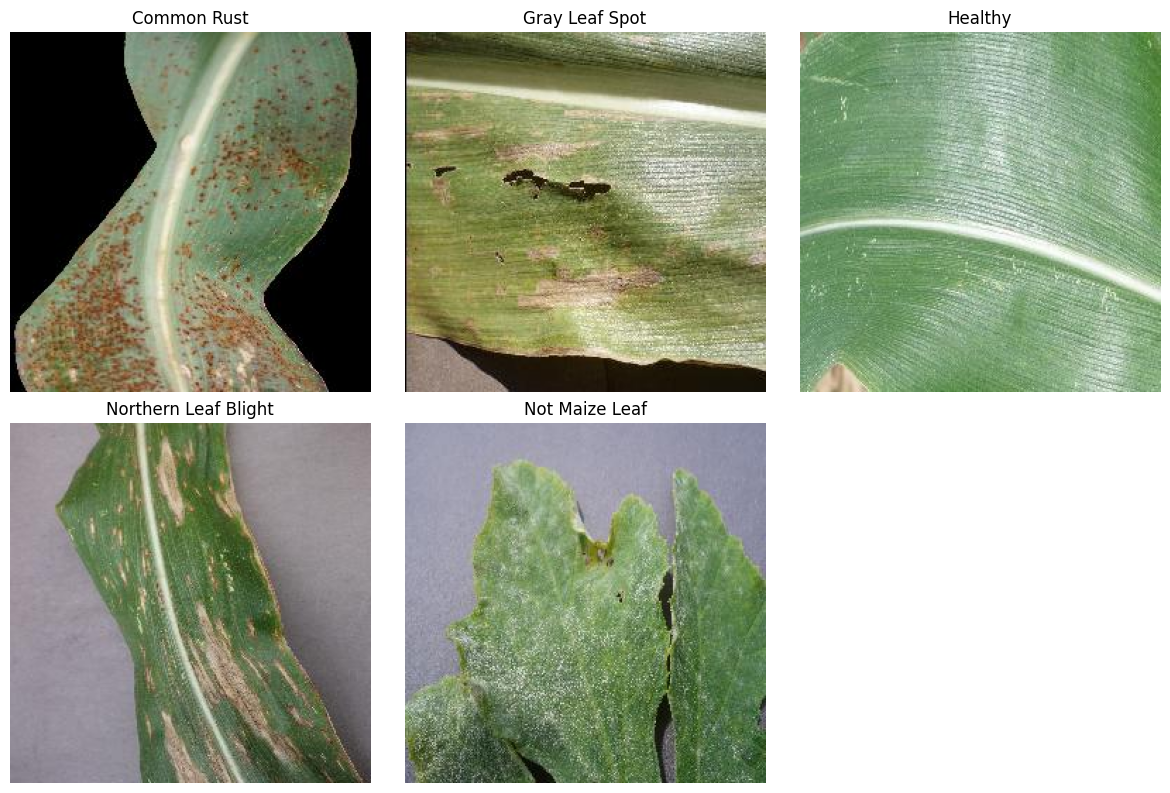

In [ ]:
classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])

plt.figure(figsize=(12, 8))
for i, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    contoh = os.listdir(cls_path)[0]
    img = plt.imread(os.path.join(cls_path, contoh))
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.tight_layout()
plt.show()

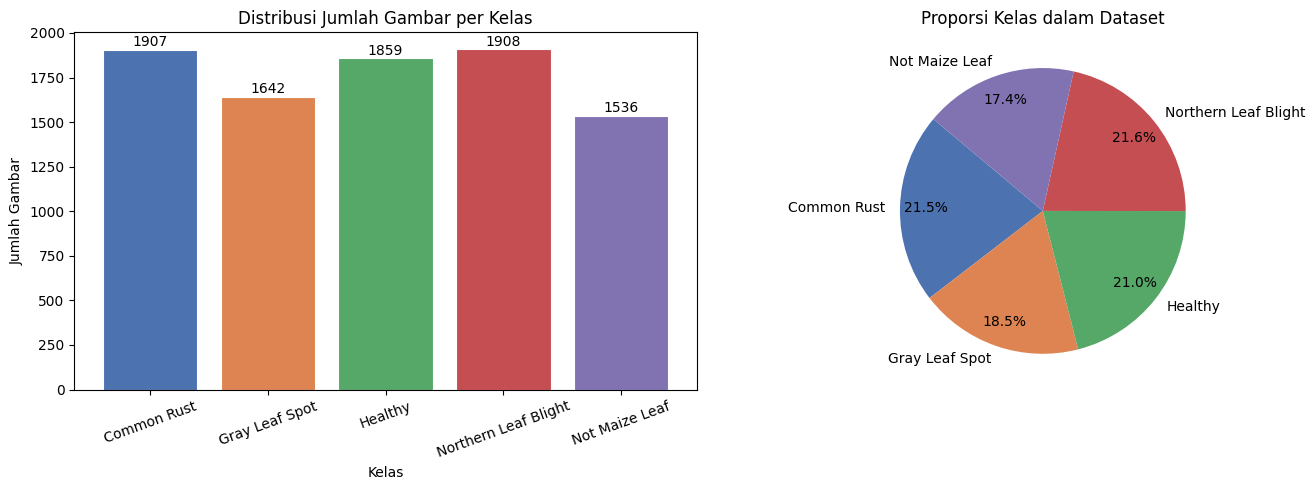

In [ ]:
# Hitung jumlah gambar per kelas
class_counts = {}
for cls in sorted(os.listdir(data_dir)):
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(os.listdir(cls_path))

labels = list(class_counts.keys())
counts = list(class_counts.values())
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(labels, counts, color=colors, edgecolor="white", linewidth=0.8)
axes[0].set_title("Distribusi Jumlah Gambar per Kelas")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Gambar")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(counts):
    axes[0].text(i, v + 20, str(v), ha="center", fontsize=10)

# Pie chart
axes[1].pie(counts, labels=labels, colors=colors, autopct="%1.1f%%",
            startangle=140, pctdistance=0.82)
axes[1].set_title("Proporsi Kelas dalam Dataset")

plt.tight_layout()
plt.show()

## 4. Membagi Data dan Membuat Pipeline

Data dibagi tiga bagian: 80 persen untuk pelatihan, lalu sisa 20 persen dipotong rata menjadi data validasi dan data uji. Keras membaca label otomatis dari nama folder, jadi tidak perlu membuat label secara manual.

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Daftar kelas:", class_names)

Found 8852 files belonging to 5 classes.
Using 7082 files for training.
Found 8852 files belonging to 5 classes.
Using 1770 files for validation.
Daftar kelas: ['Common Rust', 'Gray Leaf Spot', 'Healthy', 'Northern Leaf Blight', 'Not Maize Leaf']


In [ ]:
# Potong bagian validasi jadi dua: separuh validasi, separuh data uji
val_batches = tf.data.experimental.cardinality(val_test_ds)
test_ds = val_test_ds.take(val_batches // 2)
val_ds = val_test_ds.skip(val_batches // 2)

print("Batch latih    :", tf.data.experimental.cardinality(train_ds).numpy())
print("Batch validasi :", tf.data.experimental.cardinality(val_ds).numpy())
print("Batch uji      :", tf.data.experimental.cardinality(test_ds).numpy())

Batch latih    : 222
Batch validasi : 28
Batch uji      : 28


Supaya pelatihan lebih cepat, dataset di-cache dan di-prefetch. Untuk memperkaya variasi data latih, ditambahkan augmentasi sederhana berupa flip, rotasi, dan zoom ringan yang hanya aktif saat pelatihan.

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

## 5. Membangun Model

MobileNetV2 dipakai sebagai basis dengan bobot hasil pelatihan di ImageNet. Lapisan basisnya dibekukan dulu, lalu di atasnya dipasang classifier baru yang akan belajar membedakan kelima kelas daun jagung. Fungsi preprocess_input menyesuaikan rentang nilai piksel sesuai yang diharapkan MobileNetV2.

In [ ]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Melatih Model

Tahap pertama hanya melatih bagian classifier sementara basis MobileNetV2 tetap beku. EarlyStopping ditambahkan agar pelatihan berhenti sendiri begitu validasi berhenti membaik, sekaligus mengembalikan bobot terbaik.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

EPOCHS = 20
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop],
)

Epoch 1/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.8825 - loss: 0.3156 - val_accuracy: 0.9462 - val_loss: 0.1341
Epoch 2/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.9537 - loss: 0.1273 - val_accuracy: 0.9554 - val_loss: 0.1197
Epoch 3/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9595 - loss: 0.1089 - val_accuracy: 0.9634 - val_loss: 0.0981
Epoch 4/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.9663 - loss: 0.0912 - val_accuracy: 0.9657 - val_loss: 0.1055
Epoch 5/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.9647 - loss: 0.0936 - val_accuracy: 0.9657 - val_loss: 0.0986
Epoch 6/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.9674 - loss: 0.0863 - val_accuracy: 0.9680 - val_loss: 0.0902
Epoch 7/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.9654 - loss: 0.0879 - val_accuracy: 0.9600 - val_loss: 0.1032
Epoch 8/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - accuracy: 0.9685 - loss: 0.0812 - 

## 7. Fine-tuning

Setelah classifier cukup terlatih, sebagian lapisan atas MobileNetV2 dibuka lalu dilatih ulang dengan learning rate jauh lebih kecil. Ini biasanya dapat menaikkan akurasi karena model bisa menyesuaikan fiturnya ke karakteristik daun jagung.

In [ ]:
base_model.trainable = True

# Bekukan lapisan bawah, latih ulang lapisan atas saja
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop],
)

Epoch 1/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 38s 104ms/step - accuracy: 0.9325 - loss: 0.1945 - val_accuracy: 0.9714 - val_loss: 0.0830
Epoch 2/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.9571 - loss: 0.1203 - val_accuracy: 0.9703 - val_loss: 0.0812
Epoch 3/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - accuracy: 0.9672 - loss: 0.0860 - val_accuracy: 0.9748 - val_loss: 0.0742
Epoch 4/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.9689 - loss: 0.0801 - val_accuracy: 0.9691 - val_loss: 0.0834
Epoch 5/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 22s 100ms/step - accuracy: 0.9726 - loss: 0.0772 - val_accuracy: 0.9760 - val_loss: 0.0676
Epoch 6/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.9767 - loss: 0.0650 - val_accuracy: 0.9771 - val_loss: 0.0603
Epoch 7/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.9814 - loss: 0.0502 - val_accuracy: 0.9794 - val_loss: 0.0537
Epoch 8/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.9822 - loss: 0.0496 

## 8. Evaluasi

Bagian ini menilai model memakai data uji yang belum pernah dilihat saat pelatihan. Bagian ini juga menampilkan: grafik akurasi dan loss, akurasi akhir di data uji, confusion matrix, lalu laporan precision, recall, dan f1-score untuk tiap kelas.

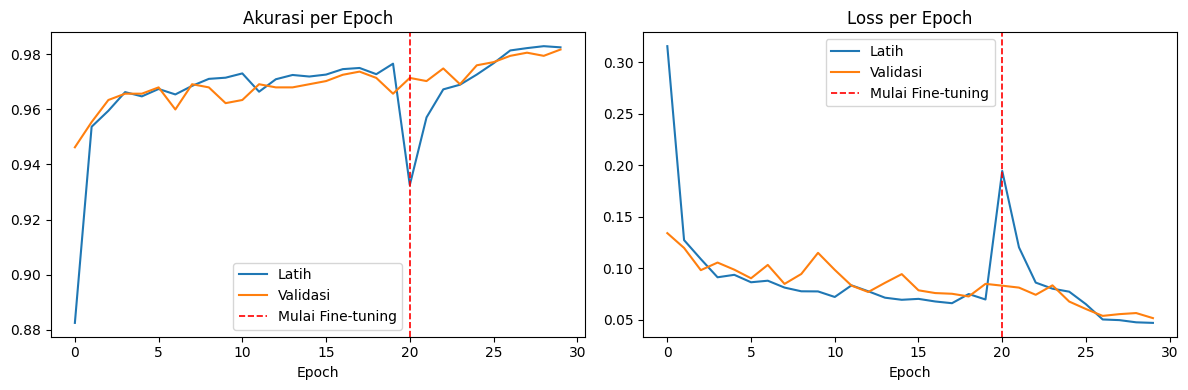

In [ ]:
initial_epochs = len(history.history["accuracy"])

acc = history.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]
loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label="Latih")
plt.plot(val_acc, label="Validasi")
plt.axvline(x=initial_epochs, color="red", linestyle="--", linewidth=1.2, label="Mulai Fine-tuning")
plt.title("Akurasi per Epoch")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label="Latih")
plt.plot(val_loss, label="Validasi")
plt.axvline(x=initial_epochs, color="red", linestyle="--", linewidth=1.2, label="Mulai Fine-tuning")
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Akurasi data uji: {test_acc:.4f}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9844 - loss: 0.0521
Akurasi data uji: 0.9844


In [ ]:
# Kumpulkan label asli dan prediksi dalam satu kali iterasi
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

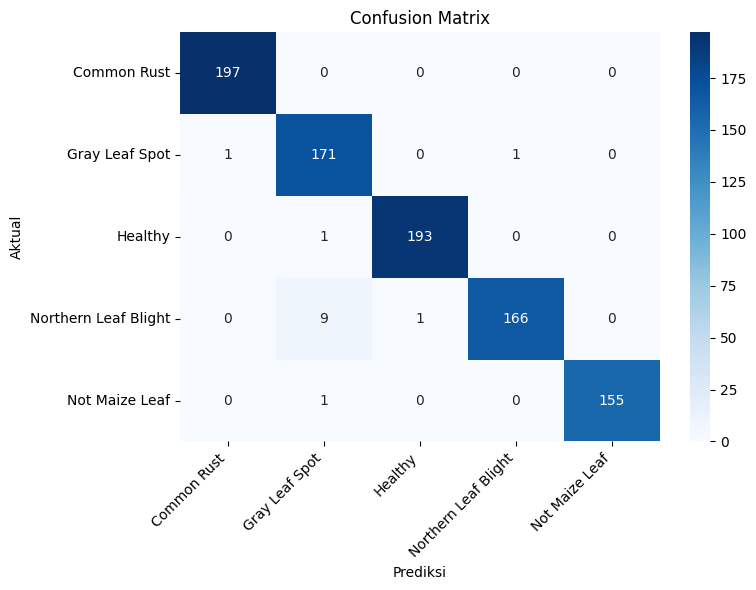

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

                      precision    recall  f1-score   support

         Common Rust     0.9949    1.0000    0.9975       197
      Gray Leaf Spot     0.9396    0.9884    0.9634       173
             Healthy     0.9948    0.9948    0.9948       194
Northern Leaf Blight     0.9940    0.9432    0.9679       176
      Not Maize Leaf     1.0000    0.9936    0.9968       156

            accuracy                         0.9844       896
           macro avg     0.9847    0.9840    0.9841       896
        weighted avg     0.9849    0.9844    0.9844       896



## 9. Uji Coba Prediksi

Untuk menguji model pada gambar baru, unggah satu file gambar lalu jalankan sel berikut. Model akan menampilkan kelas prediksi beserta tingkat keyakinannya. Coba juga dengan gambar yang bukan daun jagung untuk mengecek apakah masuk ke kelas Not Maize Leaf.

Saving tes health.jpg to tes health.jpg


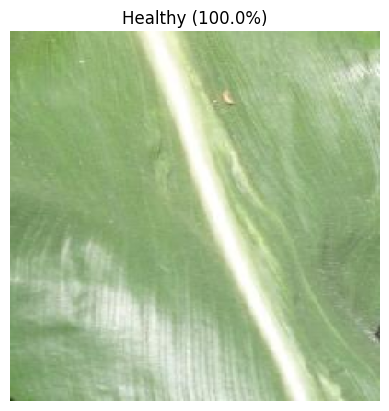

In [ ]:
uploaded = files.upload()

for fname in uploaded.keys():
    img = tf.keras.utils.load_img(fname, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    preds = model.predict(img_array, verbose=0)[0]
    pred_class = class_names[np.argmax(preds)]
    confidence = 100 * np.max(preds)

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{pred_class} ({confidence:.1f}%)")
    plt.show()

## 10. Menyimpan Model
Simpan model setelah berhasil menjalankan seluruh sel, supaya bisa dipakai lagi tanpa melatih dari awal. Karena file di Colab akan hilang begitu sesi berakhir.

In [ ]:
from google.colab import files

model.save("maize_leaf_mobilenetv2.keras")
files.download("maize_leaf_mobilenetv2.keras")
print("Model berhasil diunduh")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model berhasil diunduh
